<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/09_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 9 — Explainable AI (SHAP)

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** Module 8 answered "how likely is this account
to churn." This notebook answers the more useful question: **why**.
SHAP (SHapley Additive exPlanations) breaks each individual prediction
down into how much each feature pushed the risk score up or down — this
is what turns a black-box probability into something a retention team
can actually act on, and it's the piece most churn-prediction clones
skip entirely.

**Uses Logistic Regression** — the Module 7-selected model — which also
happens to be the easiest model type for SHAP to explain exactly and
efficiently (linear models have a closed-form SHAP solution, no
approximation needed).

**Assumes:** Modules 5, 6, 7, and 8 have been run.

## 9.1 Mount Google Drive & Install/Import SHAP

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install shap --quiet

In [3]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
MODELS_DIR = f"{PROJECT_DIR}/models"

X_train = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_train_scaled = pd.read_csv(f"{PROCESSED_DIR}/X_train_scaled.csv")
account_view = pd.read_csv(f"{PROCESSED_DIR}/account_view_engineered.csv", parse_dates=["signup_date", "churn_date"])
risk_scores = pd.read_csv(f"{PROCESSED_DIR}/account_risk_scores.csv")

scaler = joblib.load(f"{MODELS_DIR}/scaler.pkl")
log_reg = joblib.load(f"{MODELS_DIR}/logistic_regression.pkl")

print(f"shap version: {shap.__version__}")
print(f"X_train_scaled: {X_train_scaled.shape}")

shap version: 0.52.0
X_train_scaled: (400, 41)


## 9.2 Rebuild the Full Scaled Feature Matrix

Same reconstruction as Module 8 (rebuild from `account_view_engineered`,
align columns to training, scale) — repeated here rather than re-loading
a saved copy, so this notebook can also run standalone if Module 8's
intermediate matrix wasn't kept around.

In [4]:
leakage_cols = ["churn_date"]
redundant_cols = ["tenure_bucket", "usage_bucket", "mrr_bucket", "plan_tier_sub", "last_activity_date"]

df = account_view.drop(columns=[c for c in leakage_cols + redundant_cols if c in account_view.columns])
account_ids = df["account_id"].copy()
df_model = df.drop(columns=[c for c in ["account_id", "account_name"] if c in df.columns])
df_model = df_model.drop(columns=["signup_date"], errors="ignore")

categorical_cols = [c for c in ["industry", "country", "plan_tier", "billing_frequency", "referral_source"]
                     if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
bool_cols = df_model.select_dtypes(include="bool").columns.tolist()
df_model[bool_cols] = df_model[bool_cols].astype(int)

X_full = df_model.drop(columns=["churn_flag"]).reindex(columns=X_train.columns, fill_value=0)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if X_train[c].nunique() > 2]

X_full_scaled = X_full.copy()
X_full_scaled[numeric_cols] = scaler.transform(X_full[numeric_cols])

print(f"X_full_scaled: {X_full_scaled.shape}  (matches training columns: {list(X_full_scaled.columns) == list(X_train.columns)})")

X_full_scaled: (500, 41)  (matches training columns: True)


## 9.3 Build the SHAP Explainer

`shap.LinearExplainer` computes exact SHAP values for linear models
(no sampling/approximation needed, unlike tree or kernel explainers).
The training set is passed as the background distribution — SHAP values
represent each feature's contribution *relative to what's typical* in
the training data.

In [5]:
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer(X_full_scaled)

print(f"SHAP values computed for {shap_values.shape[0]} accounts across {shap_values.shape[1]} features.")

SHAP values computed for 500 accounts across 41 features.


## 9.4 Global Feature Importance

Which features matter most *across the whole customer base* — the
SHAP-based equivalent of Module 6's quick feature-importance preview,
but computed properly (mean absolute SHAP value per feature) rather
than a model-internal heuristic.

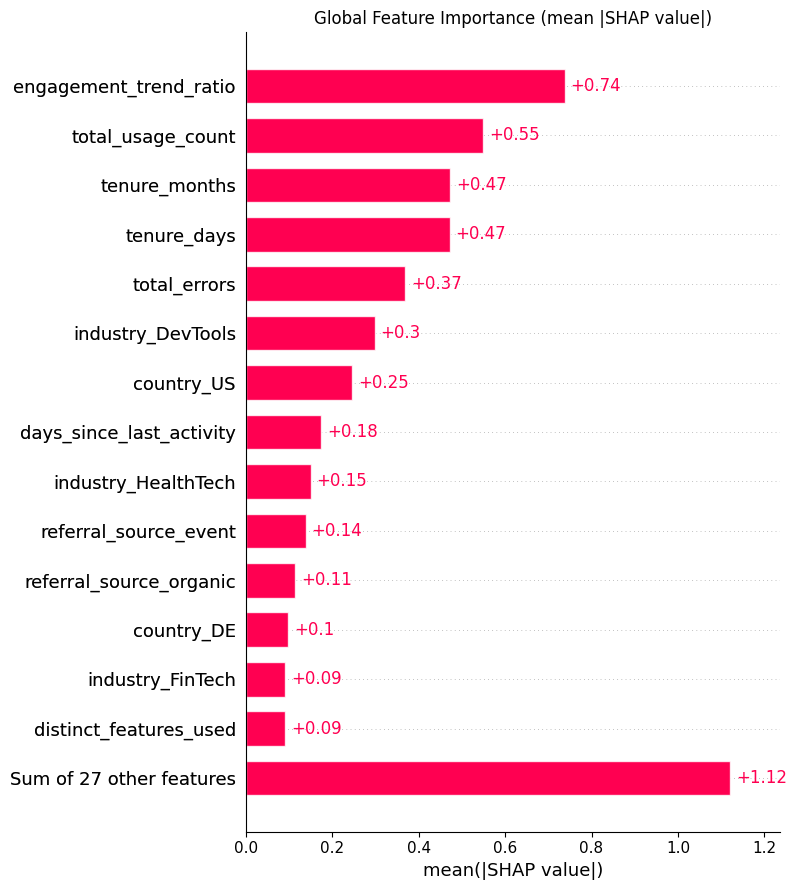

In [6]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

## 9.5 Summary Plot — Direction and Magnitude

The bar chart above shows *how much* each feature matters; this shows
*which direction* — e.g., does high `tenure_days` push risk up or down,
and how consistently across accounts.

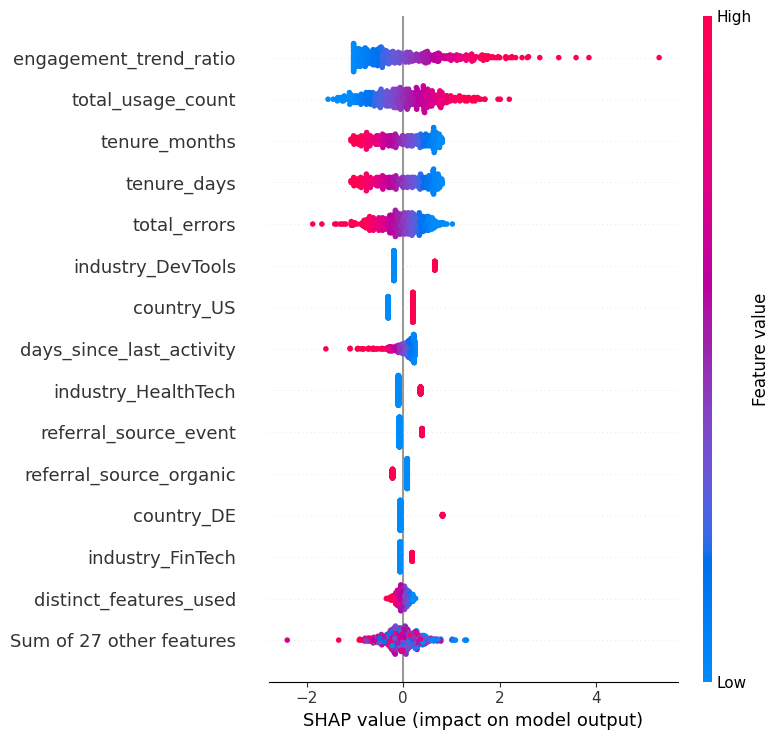

In [7]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

## 9.6 Per-Customer Explanation — High-Risk Example

This is the actual dashboard-facing output from the project plan:
"Customer #X — Churn Probability: 82% — Factors increasing/decreasing
risk." Pull one of Module 8's actual highest-risk *currently active*
accounts and explain it individually.

Explaining account: A-432483
Churn probability: 92.9%
Risk level: High


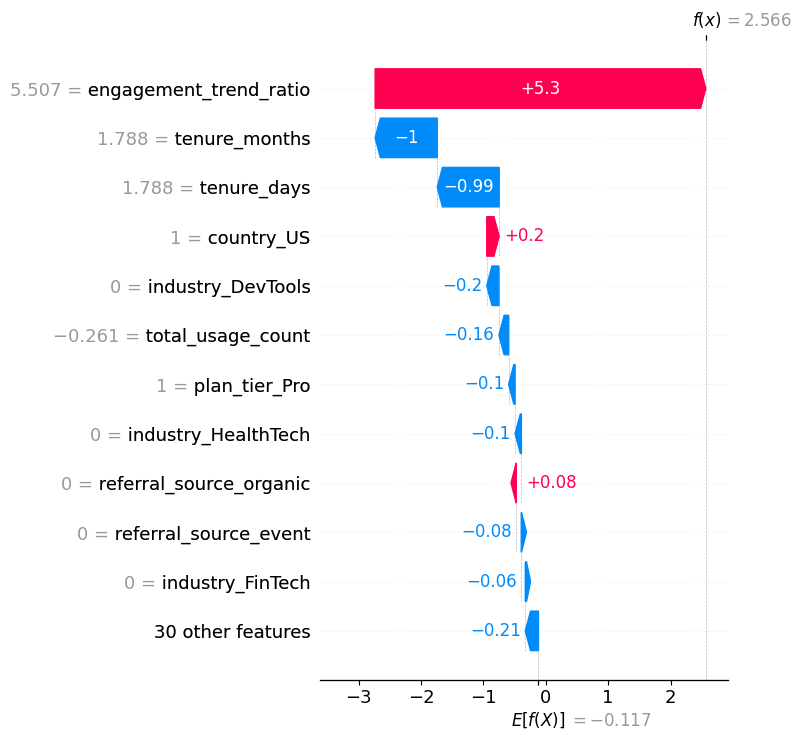

In [8]:
highest_risk_idx = risk_scores[risk_scores["churn_flag"] == False]["churn_probability"].idxmax()
example_account_id = risk_scores.loc[highest_risk_idx, "account_id"]
example_prob = risk_scores.loc[highest_risk_idx, "churn_probability"]

print(f"Explaining account: {example_account_id}")
print(f"Churn probability: {example_prob:.1%}")
print(f"Risk level: {risk_scores.loc[highest_risk_idx, 'risk_level']}")

shap.plots.waterfall(shap_values[highest_risk_idx], max_display=12, show=False)
plt.tight_layout()
plt.show()

## 9.7 Per-Customer Explanation — Second Example (Low Risk, for Contrast)

Explaining a low-risk account too makes the tool's value clearer — it's
not just "who's at risk" but "why is this account considered *safe*,"
which is equally useful for understanding what's working.

Explaining account: A-e43bf7
Churn probability: 5.1%
Risk level: Low


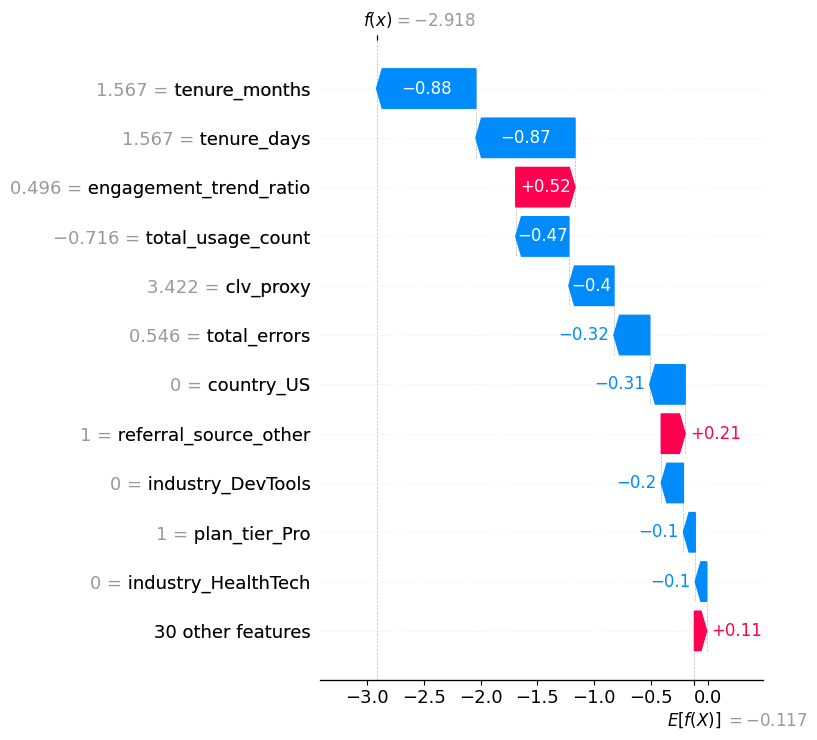

In [9]:
lowest_risk_idx = risk_scores[risk_scores["churn_flag"] == False]["churn_probability"].idxmin()
example_account_id_low = risk_scores.loc[lowest_risk_idx, "account_id"]

print(f"Explaining account: {example_account_id_low}")
print(f"Churn probability: {risk_scores.loc[lowest_risk_idx, 'churn_probability']:.1%}")
print(f"Risk level: {risk_scores.loc[lowest_risk_idx, 'risk_level']}")

shap.plots.waterfall(shap_values[lowest_risk_idx], max_display=12, show=False)
plt.tight_layout()
plt.show()

## 9.8 Extract Top Factors Per Account (For the Dashboard)

Module 13's "Customer Risk" page needs each account's top contributing
factors as plain text/values, not a matplotlib plot — extract the
top 3 risk-increasing and top 3 risk-decreasing features per account.

In [10]:
shap_df = pd.DataFrame(shap_values.values, columns=X_full_scaled.columns)
shap_df.insert(0, "account_id", account_ids.values)

shap_value_cols = list(X_full_scaled.columns)  # exact numeric columns only — computed once, used below

def top_factors(row, n=3, direction="increasing"):
    vals = row[shap_value_cols].astype(float)
    if direction == "increasing":
        top = vals.sort_values(ascending=False).head(n)
    else:
        top = vals.sort_values(ascending=True).head(n)
    return "; ".join([f"{feat} ({val:+.3f})" for feat, val in top.items()])

# Compute both from the ORIGINAL shap_df (before any text columns are
# added) — assigning the first result to a variable, not back into
# shap_df, avoids the second .apply() call picking up the first
# call's new text column and breaking the float conversion.
top_increasing = shap_df.apply(lambda r: top_factors(r, direction="increasing"), axis=1)
top_decreasing = shap_df.apply(lambda r: top_factors(r, direction="decreasing"), axis=1)

shap_df["top_risk_increasing"] = top_increasing
shap_df["top_risk_decreasing"] = top_decreasing

factors_export = shap_df[["account_id", "top_risk_increasing", "top_risk_decreasing"]]
print(factors_export.head(5).to_string(index=False))

account_id                                                                top_risk_increasing                                                                      top_risk_decreasing
  A-2e4581                  tenure_months (+0.614); tenure_days (+0.613); country_US (+0.200) engagement_trend_ratio (-0.837); total_errors (-0.430); referral_source_partner (-0.195)
  A-43a9e3        engagement_trend_ratio (+0.494); total_errors (+0.484); country_IN (+0.328)                 total_usage_count (-0.530); tenure_months (-0.495); tenure_days (-0.494)
  A-0a282f     total_usage_count (+1.291); industry_DevTools (+0.654); tenure_months (+0.484)  total_errors (-0.810); engagement_trend_ratio (-0.607); distinct_features_used (-0.226)
  A-1f0ac7 engagement_trend_ratio (+0.635); industry_HealthTech (+0.358); country_UK (+0.227)                 tenure_months (-0.469); tenure_days (-0.468); total_usage_count (-0.425)
  A-ce550d       tenure_months (+0.651); tenure_days (+0.649); referral_source_event 

## 9.9 SHAP — Key Findings

Based on the actual mean |SHAP value| ranking:

- **Top global drivers:** `engagement_trend_ratio` (0.738),
  `total_usage_count` (0.550), `tenure_months`/`tenure_days` (~0.47
  each — expected, since they're near-duplicates of each other),
  `total_errors` (0.370). Notably, `engagement_trend_ratio` — Module 5's
  custom-built behavioral feature — is the single strongest driver by
  SHAP, ahead of every raw aggregate. That's a genuinely good sign for
  the feature engineering work in Module 5, worth highlighting in the
  README.
- **Direction of effect — verified, not assumed:** checking the actual
  relationship (not just eyeballing the beeswarm plot), a **higher**
  `engagement_trend_ratio` pushes risk **up**, not down — the opposite
  of the standard "declining usage precedes churn" hypothesis. This is
  consistent with Module 5 section 5.9's own honest finding (churned
  accounts averaged a *higher* trend ratio than retained accounts), so
  SHAP is confirming the same counter-intuitive pattern, not
  contradicting it. Worth stating directly in the README rather than
  assuming the textbook direction applies here — and worth noting this
  is likely the same first-half/second-half window artifact flagged in
  Module 5, not necessarily a genuine reversal of the usual SaaS
  pattern. (Also worth knowing for a technical audience: because
  Logistic Regression is linear, each feature's SHAP value is *exactly*
  proportional to that feature's own scaled value — a perfect monotonic
  relationship, unlike tree-based SHAP which can capture interactions.)
- **Consistency with earlier modules:** `tenure_days` and
  `total_usage_count` were already flagged as relevant in Module 6's
  Random Forest feature importance — SHAP confirms them here with a
  more rigorous, per-prediction method rather than a single model-
  internal heuristic.
- **Business framing:** consistent with the honest "no dominant driver"
  finding from Modules 2 and 5, SHAP contributions for individual
  accounts are genuinely diffuse — the waterfall plots in 9.6/9.7 show
  several small-to-moderate factors stacking up rather than one huge
  driver, which matches the weak overall correlations found throughout
  this project. This is an honest characteristic of the dataset, not a
  limitation of SHAP itself, and worth stating plainly in the README.

## 9.10 Save SHAP Outputs

Persist per-account top factors and raw SHAP values for the dashboard
and for Module 12 (Recommendation Layer) to build on.

In [11]:
factors_export.to_csv(f"{PROCESSED_DIR}/account_shap_factors.csv", index=False)
shap_df.to_csv(f"{PROCESSED_DIR}/shap_values_full.csv", index=False)

print(f"Saved account_shap_factors.csv and shap_values_full.csv to {PROCESSED_DIR}")

Saved account_shap_factors.csv and shap_values_full.csv to /content/drive/MyDrive/saas-retention-intelligence/data/processed


## 9.11 Module 9 Summary

- Built a `LinearExplainer` for the Module 7-selected Logistic
  Regression model — exact SHAP values, no approximation needed
- Computed SHAP values for all 500 accounts
- Visualized global feature importance and direction of effect
  (bar chart + beeswarm plot)
- Produced individual per-customer explanations for a high-risk and a
  low-risk example — the actual dashboard-facing deliverable from the
  project plan
- Extracted top risk-increasing/decreasing factors per account and
  saved for Module 13's dashboard

**Next:** Module 10 — Revenue at Risk